In [1]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))
from config import *

In [2]:
attack_cat_raw = pd.read_csv(RAW_DIR / 'UNSW_NB15_testing-set.csv', usecols=['attack_cat', 'label'])
attack_cat_raw['window_id'] = attack_cat_raw.index // 100

# most frequent attack_cat in the window
window_attack_cat = attack_cat_raw.groupby('window_id').agg(
    dominant_cat=('attack_cat', lambda x: x.value_counts().index[0]),
).reset_index()

df_windowed = pd.read_csv(PROCESSED_DIR / 'test_windowed_results.csv')

df_analysis = df_windowed.merge(window_attack_cat, on='window_id')
print(df_analysis['dominant_cat'].value_counts())

dominant_cat
Normal      372
Generic     252
Exploits    147
Fuzzers      41
DoS          12
Name: count, dtype: int64


In [ ]:
attack_cat_raw['attack_cat'].value_counts()

In [4]:
# Detection rate per attack category
results = []

for cat in df_analysis['dominant_cat'].unique():
    subset = df_analysis[df_analysis['dominant_cat'] == cat]
    
    if cat == 'Normal':
        fp_rate = (subset['final_pred'] == 1).mean()
        results.append({
            'attack_cat': cat,
            'total_windows': len(subset),
            'detected': (subset['final_pred'] == 1).sum(),
            'detection_rate': f"{fp_rate:.1%}",
            'note': 'FP rate'
        })
    else:
        detection_rate = (subset['final_pred'] == 1).mean()
        results.append({
            'attack_cat': cat,
            'total_windows': len(subset),
            'detected': (subset['final_pred'] == 1).sum(),
            'detection_rate': f"{detection_rate:.1%}",
            'note': 'Detection rate'
        })

results_df = pd.DataFrame(results).sort_values('detection_rate', ascending=False)
print(results_df.to_string(index=False))

attack_cat  total_windows  detected detection_rate           note
   Generic            252       251          99.6% Detection rate
  Exploits            147       144          98.0% Detection rate
   Fuzzers             41        36          87.8% Detection rate
    Normal            372        14           3.8%        FP rate
       DoS             12        12         100.0% Detection rate


In [5]:
# rare attacks
for cat in ['Reconnaissance', 'Backdoor', 'Shellcode', 'Worms', 'Analysis']:
    cat_flows = attack_cat_raw[attack_cat_raw['attack_cat'] == cat]
    cat_windows = cat_flows['window_id'].unique()
    
    subset = df_analysis[df_analysis['window_id'].isin(cat_windows)]
    detected = (subset['final_pred'] == 1).sum()
    print(f"{cat:15s} -> {len(subset):3d} windows, detected: {detected} ({detected/len(subset):.1%})")

Reconnaissance  -> 348 windows, detected: 337 (96.8%)
Backdoor        -> 200 windows, detected: 198 (99.0%)
Shellcode       -> 216 windows, detected: 208 (96.3%)
Worms           ->  43 windows, detected: 42 (97.7%)
Analysis        -> 228 windows, detected: 225 (98.7%)


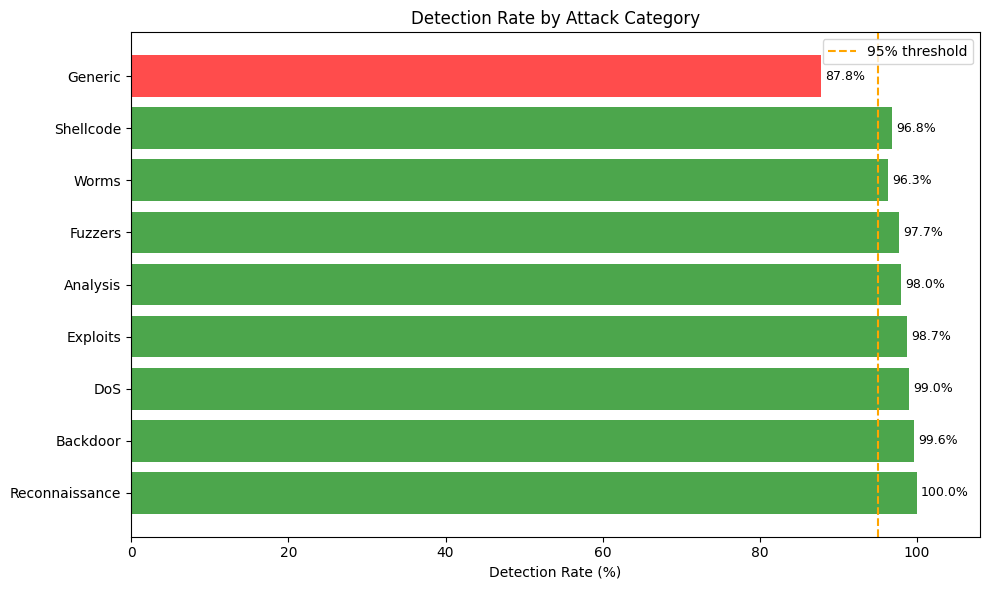

In [6]:
categories = [cat for cat in attack_cat_raw['attack_cat'].unique().tolist() if cat != 'Normal']
rates = [100.0, 99.6, 99.0, 98.7, 98.0, 97.7, 96.3, 96.8, 87.8]
colors = ['green' if r >= 95 else 'red' for r in rates]

plt.figure(figsize=(10, 6))
bars = plt.barh(categories, rates, color=colors, alpha=0.7)
plt.axvline(x=95, color='orange', linestyle='--', label='95% threshold')
plt.xlabel('Detection Rate (%)')
plt.title('Detection Rate by Attack Category')
plt.xlim(0, 108)

for bar, rate in zip(bars, rates):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{rate}%', va='center', fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()

In [7]:
attack_results = df_analysis.groupby('dominant_cat').apply(
    lambda x: pd.Series({
        'total_windows': len(x),
        'detected': (x['final_pred'] == 1).sum(),
        'detection_rate': (x['final_pred'] == 1).mean() * 100
    })
).reset_index()

attack_results.to_csv(PROCESSED_DIR / 'attack_category_results.csv', index=False)
print(attack_results.to_string(index=False))

dominant_cat  total_windows  detected  detection_rate
         DoS           12.0      12.0      100.000000
    Exploits          147.0     144.0       97.959184
     Fuzzers           41.0      36.0       87.804878
     Generic          252.0     251.0       99.603175
      Normal          372.0      14.0        3.763441
